In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

In [ ]:
# =====================================================
# Fisher-KPP Parameters
# =====================================================

D = 0.01
R = 2.0

print(f"Diffusion coefficient D = {D}")
print(f"Reaction coefficient R = {R}")

Diffusion coefficient D = 0.01
Reaction coefficient R = 2.0


In [ ]:
# =====================================================
# Computational Domain
# =====================================================

x_min = 0.0
x_max = 1.0

t_min = 0.0
t_max = 1.0

Nx = 201
Nt = 3200 # Doubled Nt for better stability with increased R

x = np.linspace(x_min, x_max, Nx)
t = np.linspace(t_min, t_max, Nt)

dx = x[1] - x[0]
dt = t[1] - t[0]

print(f"dx = {dx}")
print(f"dt = {dt}")

dx = 0.005
dt = 0.00031259768677711783


In [ ]:
# =====================================================
# Mesh Generation
# =====================================================

X, T = np.meshgrid(x, t)

print("X shape =", X.shape)
print("T shape =", T.shape)

X shape = (3200, 201)
T shape = (3200, 201)


In [ ]:
# =====================================================
# FTCS Stability Check
# =====================================================

lambda_fdm = D * dt / dx**2

print("="*50)
print("STABILITY ANALYSIS")
print("="*50)

print(f"Diffusion stability parameter (lambda_fdm) = {lambda_fdm}")

# Full stability condition for Fisher-KPP FTCS scheme
# Simplified linear stability: dt * (R + 2*D/dx**2) <= 1
full_stability_check_value = dt * (R + 2*D/dx**2)
print(f"Full stability check value (dt * (R + 2*D/dx**2)) = {full_stability_check_value}")

if full_stability_check_value <= 1.0:
    print("Stable FTCS Scheme (based on linearized stability criteria)")
elif lambda_fdm <= 0.5:
    print("WARNING: Scheme might be unstable due to reaction term, even if diffusion part is stable.")
    print("Consider increasing Nt further to decrease dt.")
else:
    print("WARNING: Unstable FTCS Scheme (diffusion part is unstable)")
    print("Consider increasing Nt further to decrease dt or decreasing Nx to increase dx.")

STABILITY ANALYSIS
Diffusion stability parameter (lambda_fdm) = 0.12503907471084713
Full stability check value (dt * (R + 2*D/dx**2)) = 0.2507033447952485
Stable FTCS Scheme (based on linearized stability criteria)


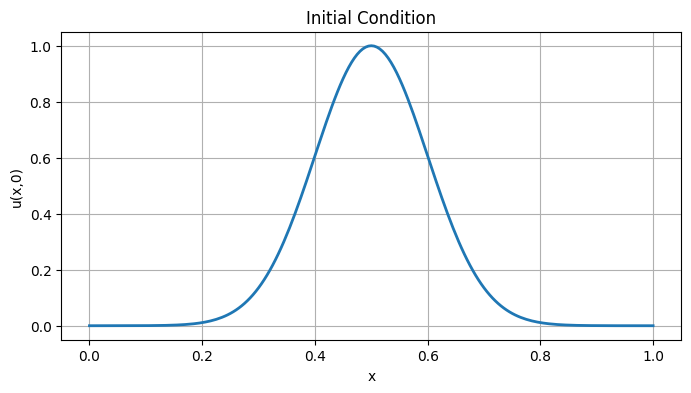

In [ ]:
# =====================================================
# Initial Condition
# u(x,0)=exp(-50(x-0.5)^2)
# =====================================================

u0 = np.exp(-50*(x - 0.5)**2)

plt.figure(figsize=(8,4))
plt.plot(x, u0, linewidth=2)
plt.xlabel("x")
plt.ylabel("u(x,0)")
plt.title("Initial Condition")
plt.grid(True)
plt.show()

In [ ]:
# =====================================================
# Solution Matrix
# =====================================================

U = np.zeros((Nt, Nx))

U[0,:] = u0

print("Solution matrix shape:", U.shape)

Solution matrix shape: (3200, 201)


In [ ]:
# =====================================================
# Dirichlet Boundary Conditions
# u(0,t)=0
# u(1,t)=0
# =====================================================

U[:,0] = 0.0
U[:,-1] = 0.0

In [ ]:
# =====================================================
# FTCS Solver
# =====================================================

for n in range(Nt - 1):

    for i in range(1, Nx - 1):

        diffusion = (
            D *
            (U[n,i+1] - 2*U[n,i] + U[n,i-1])
            / dx**2
        )

        reaction = (
            R *
            U[n,i] *
            (1 - U[n,i])
        )

        U[n+1,i] = (
            U[n,i]
            + dt*(diffusion + reaction)
        )

    U[n+1,0] = 0.0
    U[n+1,-1] = 0.0

print("Simulation completed.")

Simulation completed.


In [ ]:
print("Minimum value =", np.min(U))
print("Maximum value =", np.max(U))

Minimum value = 0.0
Maximum value = 1.0


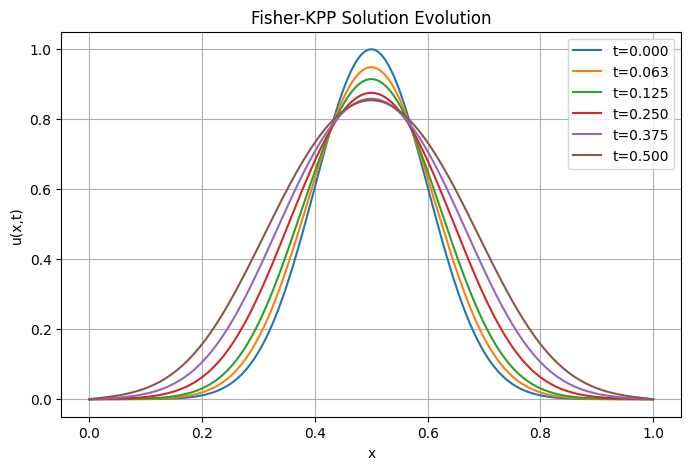

In [ ]:
plt.figure(figsize=(8,5))

indices = [0, 200, 400, 800, 1200, 1599]

for idx in indices:
    plt.plot(
        x,
        U[idx,:],
        label=f"t={t[idx]:.3f}"
    )

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Fisher-KPP Solution Evolution")
plt.legend()
plt.grid(True)
plt.show()

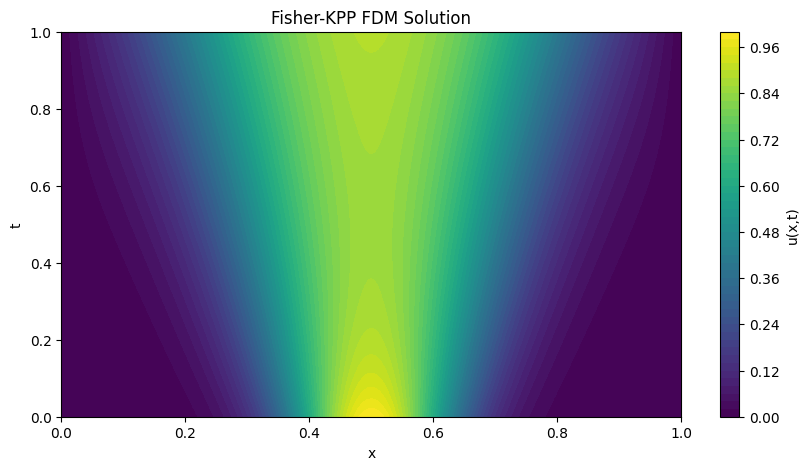

In [ ]:
plt.figure(figsize=(10,5))

contour = plt.contourf(
    X,
    T,
    U,
    levels=50
)

plt.colorbar(contour,label="u(x,t)")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Fisher-KPP FDM Solution")
plt.show()

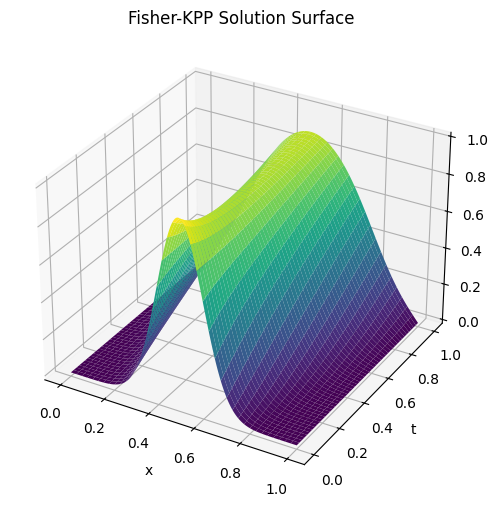

In [ ]:
fig = plt.figure(figsize=(10,6))

ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(
    X,
    T,
    U,
    cmap='viridis'
)

ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('u')

ax.set_title('Fisher-KPP Solution Surface')

plt.show()

In [ ]:
# =====================================================
# Convert FDM Solution to Dataset
# =====================================================

dataset = pd.DataFrame({
    "x": X.flatten(),
    "t": T.flatten(),
    "u": U.flatten()
})

print(dataset.head())
print("\nShape =", dataset.shape)

       x    t         u
0  0.000  0.0  0.000000
1  0.005  0.0  0.000005
2  0.010  0.0  0.000006
3  0.015  0.0  0.000008
4  0.020  0.0  0.000010

Shape = (643200, 3)


In [ ]:
dataset.to_csv(
    "FisherKPP_Inverse_PINN_Dataset2.csv",
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.


In [ ]:
from google.colab import files

files.download(
    "FisherKPP_Inverse_PINN_Dataset2.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>